# Exploración y visualización de datos en aprendizaje automático relacional

## Dataset Cora

El dataset Cora es un conjunto de datos comúnmente utilizado en el campo del aprendizaje automático relacional. Contiene información sobre artículos científicos y sus relaciones, como citas y temas. Este dataset es útil para tareas como la clasificación de documentos, la detección de comunidades y la predicción de enlaces.

### Paso 1: importar las bibliotecas necesarias



In [ ]:
# verifica que el entorno virtual esté activo
import sys
print(sys.executable)

/home/juanan/aprendizaje-automatico-relacional/venv/bin/python


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns 
from pathlib import Path

# configuración de estilo para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Directorio base del proyecto
BASE_DIR = Path.cwd().parent

# Ruta al dataset
data_path = BASE_DIR / 'data' / 'cora'

# Ruta para guardar las figuras
figs_path = BASE_DIR / 'docs' / 'trabajo' / 'figuras'


### Paso 2: cargar el dataset Cora

In [18]:
# Carga contenido (nodos, etiquetas, características)
# cora.content tiene el formato: <paper_id> <word_attributes>+ <class_label>

path_cora_data = data_path / 'cora.content'

cora_content = pd.read_csv(path_cora_data, sep='\t', header=None)

print(cora_content.info())
print("---" * 50)

# Extraer IDs, características (features) y etiquetas
paper_ids = cora_content.iloc[:, 0].astype(str)  # IDs como strings
features = cora_content.iloc[:, 1:-1]
labels = cora_content.iloc[:, -1]

# crear un dataset más limpio para exploración estadística
df_nodes = pd.DataFrame({
    'paper_id': paper_ids,
    'label': labels})


# Carga citas (aristas)
# cora.cites tiene el formato: <cited_paper_id> <citing_paper_id>
path_cora_cites = data_path / 'cora.cites'
cora_cites = pd.read_csv(path_cora_cites, sep='\t', header=None, names=['cited_paper_id', 'citing_paper_id'])
cora_cites['cited_paper_id'] = cora_cites['cited_paper_id'].astype(str)



print(f"Número de nodos (papers): {len(df_nodes)}")
print(f"Número de características por nodo: {features.shape[1]}")
print(f"Número de clases (labels): {labels.nunique()}")
print(f"Número de aristas (citas): {len(cora_cites)}")  




<class 'pandas.DataFrame'>
RangeIndex: 2708 entries, 0 to 2707
Columns: 1435 entries, 0 to 1434
dtypes: int64(1434), str(1)
memory usage: 29.6 MB
None
------------------------------------------------------------------------------------------------------------------------------------------------------
Número de nodos (papers): 2708
Número de características por nodo: 1433
Número de clases (labels): 7
Número de aristas (citas): 5429


### Paso 3: exploración visual 1 - Distribución de clases

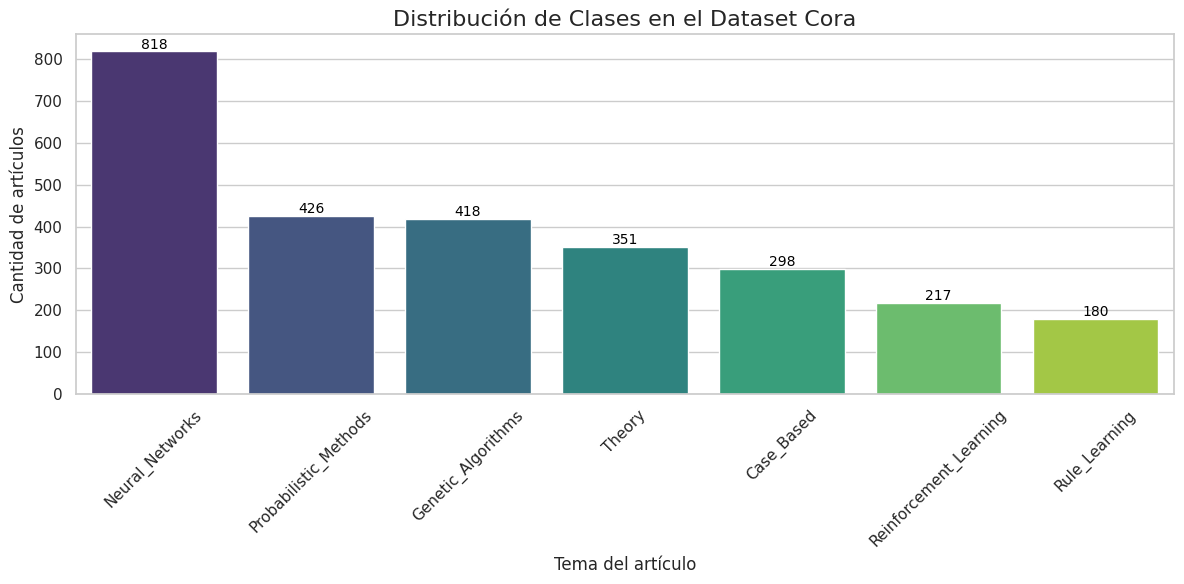

In [ ]:
plt.figure(figsize=(12, 6))
order = df_nodes['label'].value_counts().index
ax = sns.countplot(data=df_nodes, x='label', hue='label', order=order, hue_order=order, palette='viridis', legend=False)
plt.title('Distribución de Clases en el Dataset Cora', fontsize=16)
plt.xlabel('Tema del artículo', fontsize=12)
plt.ylabel('Cantidad de artículos', fontsize=12)
plt.xticks(rotation=45)

# añade el conteo excato sabre cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
# guardar figura
plt.savefig(figs_path / 'distribucion_clases_cora.png', dpi=300, bbox_inches='tight')
plt.show()



#### Interpretación de la gráfica de distribución de clases

La gráfica muestra la distribución de artículos por tema en el dataset Cora. Se puede observar que algunas clases tienen significativamente más artículos que otras, lo que indica un desequilibrio en el dataset. Este desequilibrio puede afectar el rendimiento de los modelos de aprendizaje automático, especialmente aquellos sensibles a la distribución de clases.

Concretamente los artículos relacionados con "Neural Networks" son los más numerosos, mientras que temas como "Rule Learning" tienen menos representación. **Este tipo de distribución puede requerir técnicas de balanceo de clases o enfoques específicos para manejar el desequilibrio durante el entrenamiento de modelos.**

### Paso 4: Exploración Estadística y Visual 2 - Grados del Grafo

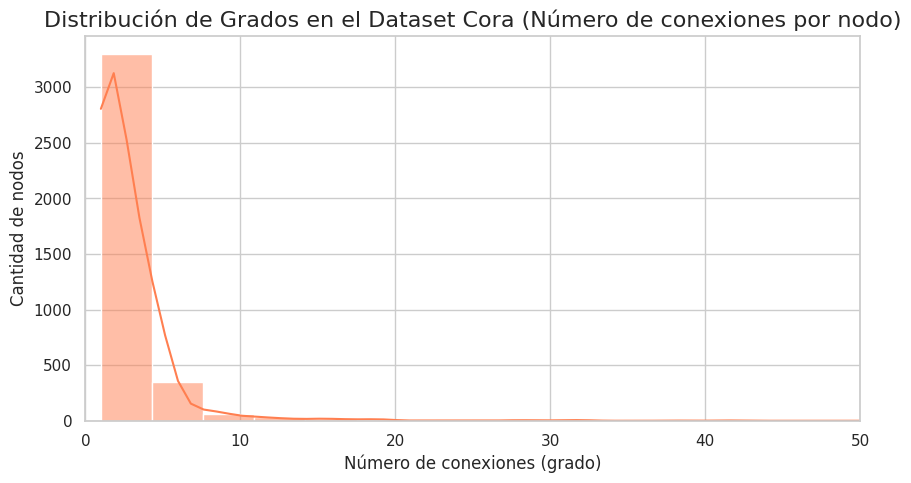

Grado máximo (nodo más conectado): 166
Grado promedio: 2.87


In [28]:
# Crear el grado con networkx
G = nx.from_pandas_edgelist(cora_cites, source='cited_paper_id', target='citing_paper_id')

# Calcular el grado de cada nodo (conexiones)
degrees = [G.degree(node) for node in G.nodes()]

plt.figure(figsize=(10, 5))
sns.histplot(degrees, bins=50, kde=True, color='coral')
plt.title('Distribución de Grados en el Dataset Cora (Número de conexiones por nodo)', fontsize=16)
plt.xlabel('Número de conexiones (grado)', fontsize=12)
plt.ylabel('Cantidad de nodos', fontsize=12)
plt.xlim(0, 50)  # Limitar el eje x para mejor visualización
# Guardar figura
plt.savefig(figs_path / 'distribucion_grados_cora.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Grado máximo (nodo más conectado): {max(degrees)}")
print(f"Grado promedio: {np.mean(degrees):.2f}")

### Paso 5: Exploración Visual 3 - Topología del Grafo (Subgrafo)

Dibujar los 2708 nodos de Cora a la vez creará una "bola de pelo" incomprensible. Una técnica para solucionar esto es muestrear un subgrafo 
(por ejemplo, tomar un artículo importante y ver su vecindario) coloreando los nodos según su clase para visualizar la homofilia 
(si los artículos del mismo color están agrupados).

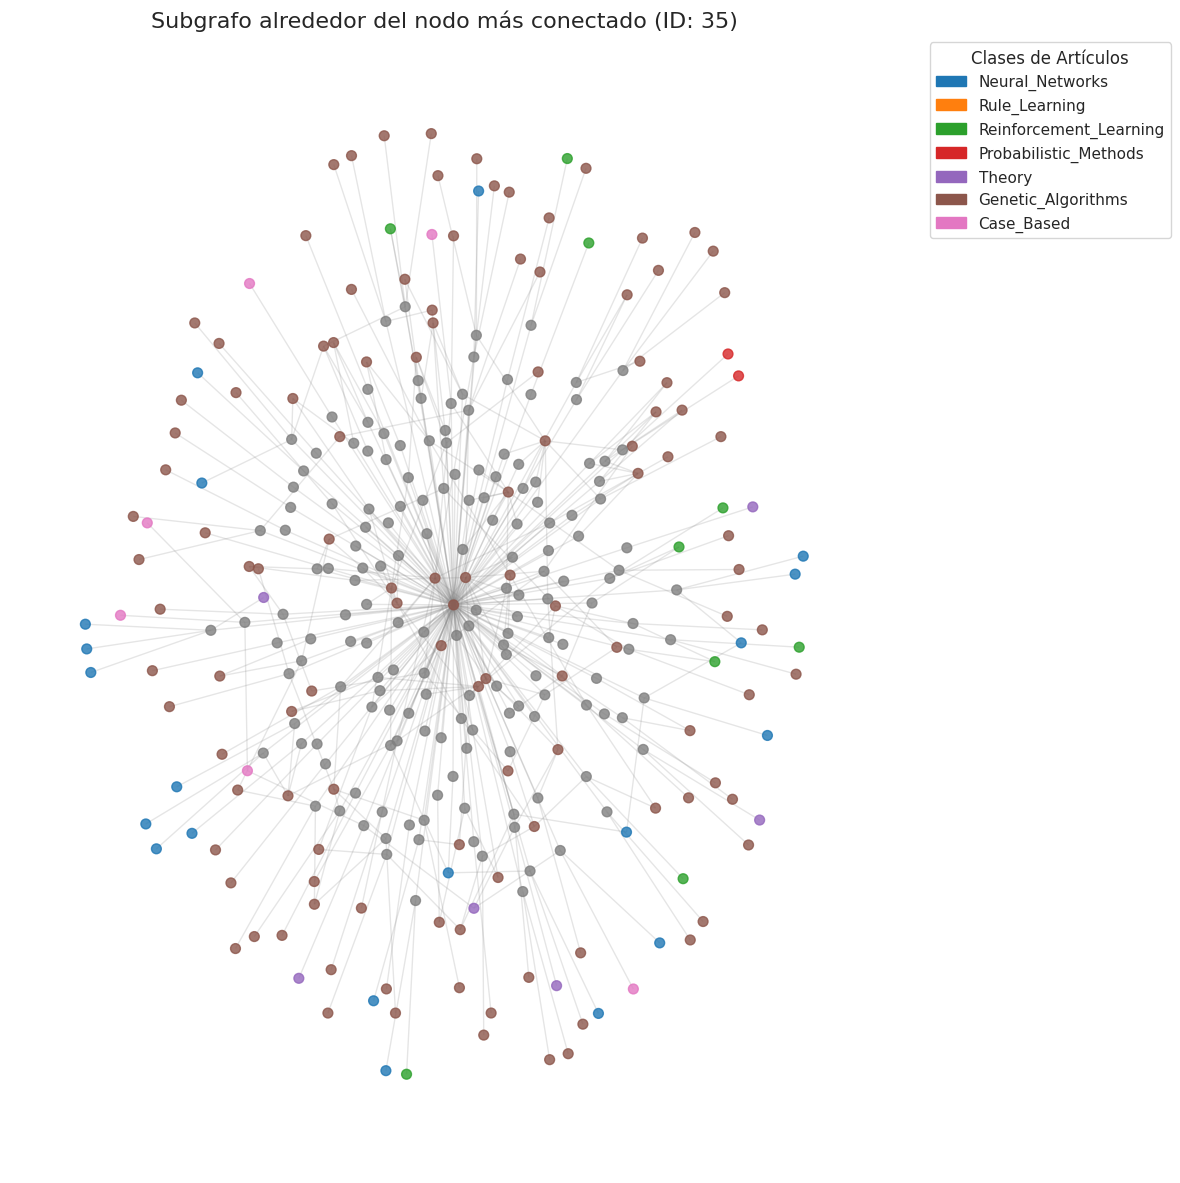

In [29]:
# Mapear colores a las clases para la visualización
unique_labels = df_nodes['label'].unique()
color_map_dict = {label: sns.color_palette("tab10")[i % 10] for i, label in enumerate(unique_labels)}
node_colors_dict = df_nodes.set_index('paper_id')['label'].map(color_map_dict).to_dict()

# Seleccionar el nodo con más conexiones para ver su vecindario
highest_degree_node = max(G.nodes, key=G.degree)
# Obtener los vecinos a distancia 1 y 2
ego_graph = nx.ego_graph(G, highest_degree_node, radius=2)

# Colores solo para los nodos en este subgrafo
colors = [node_colors_dict.get(node, (0.5, 0.5, 0.5)) for node in ego_graph.nodes()]

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(ego_graph, seed=42, k=0.15) # k ajusta la distancia entre nodos
nx.draw_networkx_nodes(ego_graph, pos, node_size=50, node_color=colors, alpha=0.8)
nx.draw_networkx_edges(ego_graph, pos, alpha=0.2, edge_color='gray')

# Crear leyenda
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=color_map_dict[label], label=label) for label in unique_labels]
plt.legend(handles=legend_handles, title="Clases de Artículos", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title(f'Subgrafo alrededor del nodo más conectado (ID: {highest_degree_node})', fontsize=16)
plt.axis('off')
plt.tight_layout()
# guardar figura
plt.savefig(figs_path / 'subgrafo_nodo_mas_conectado_cora.png', dpi=300, bbox_inches='tight')
plt.show()

### Paso 6: Análisis de Propiedades Nativas (Características)

--- Análisis de Propiedades Nativas ---
Dimensiones de la matriz de características: (2708, 1433)
Porcentaje de dispersión (Sparsity): 98.73%
Promedio de palabras clave (atributos) presentes por artículo: 18.17


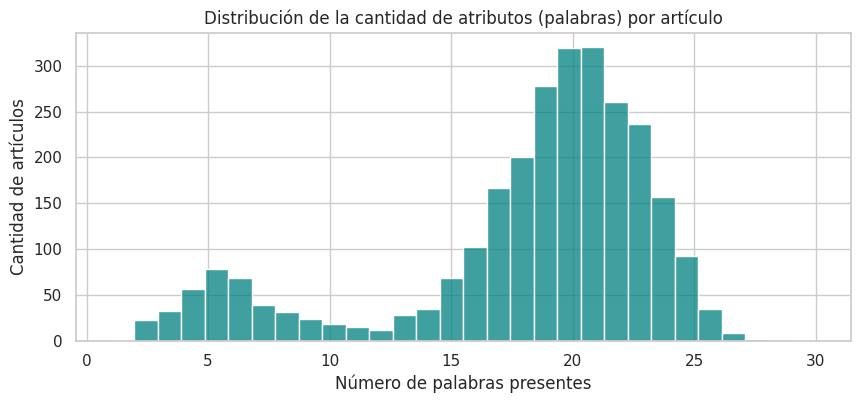

In [30]:

# features es el dataframe que contiene las 1433 columnas de palabras
print("--- Análisis de Propiedades Nativas ---")
total_elementos = features.size
valores_activos = features.sum().sum() # Suma de todos los 1s
sparsity = 100 - ((valores_activos / total_elementos) * 100)

print(f"Dimensiones de la matriz de características: {features.shape}")
print(f"Porcentaje de dispersión (Sparsity): {sparsity:.2f}%")
print(f"Promedio de palabras clave (atributos) presentes por artículo: {valores_activos / len(features):.2f}")

# Visualizar cuántos atributos tiene cada artículo
plt.figure(figsize=(10, 4))
sns.histplot(features.sum(axis=1), bins=30, color='teal')
plt.title('Distribución de la cantidad de atributos (palabras) por artículo')
plt.xlabel('Número de palabras presentes')
plt.ylabel('Cantidad de artículos')

# guardar figura
plt.savefig(figs_path / 'distribucion_palabras_por_articulo_cora.png', dpi=300, bbox_inches='tight')    
plt.show()

